In [1]:
%pip install numpy pandas matplotlib seaborn scikit-learn pymongo


Note: you may need to restart the kernel to use updated packages.


# 📊 Análisis de Correlación y Separabilidad - fact_abastecimiento_logistica

## Objetivo:
1. Cargar datos desde MongoDB
2. Calcular matriz de correlación
3. Identificar features redundantes (correlación > 0.9)
4. Visualizar en t-SNE 2D para ver separabilidad de clases
5. Recomendaciones de reducción de características

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import QuantileTransformer
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
import pymongo
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo visual
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


In [3]:
# Conectar a MongoDB y cargar datos
try:
    client = pymongo.MongoClient("mongodb://localhost:27017/")
    db = client["ProyectoBueno"]
    collection = db["fact_abastecimiento"]
    data = list(collection.find())
    print(f"✅ Conexión exitosa. Registros cargados: {len(data)}")
except Exception as e:
    print(f"❌ Error: {e}")
    print("Asegúrate de que MongoDB esté corriendo")

✅ Conexión exitosa. Registros cargados: 2500


In [4]:
# Aplanar registros recursivamente
def flatten_dict(d, parent_key='', sep='_'):
    items = []
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else k
        if isinstance(v, dict):
            items.extend(flatten_dict(v, new_key, sep=sep).items())
        elif isinstance(v, list):
            items.append((new_key, str(v)))
        else:
            items.append((new_key, v))
    return dict(items)

flat_data = [flatten_dict(record) for record in data]
df_raw = pd.DataFrame(flat_data)
print(f"\n📊 Dimensiones iniciales: {df_raw.shape}")
print(f"\nTipos de datos:")
print(df_raw.dtypes.value_counts())


📊 Dimensiones iniciales: (2500, 74)

Tipos de datos:
str        40
int64      28
float64     6
Name: count, dtype: int64


In [5]:
df = df_raw.copy()

# Crear target: entrega satisfactoria (cantidad_recibida >= 0.90 * cantidad_solicitada)
if 'cantidad_recibida' in df.columns and 'cantidad_solicitada' in df.columns:
    ratio = df['cantidad_recibida'] / df['cantidad_solicitada']
    y = pd.cut(ratio, bins=3, labels=[0, 1, 2]).astype(int)
    print(f"✅ Target MULTICLASE creado automáticamente (3 clases)")
else:
    # Si no existen esas columnas, usar otra métrica
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        y = (df[numeric_cols[0]] > df[numeric_cols[0]].median()).astype(int)
        print(f"⚠️ Target creado automáticamente")
    
print(f"\nDistribución de clases:")
print(y.value_counts().sort_index())

✅ Target MULTICLASE creado automáticamente (3 clases)

Distribución de clases:
0    799
1    893
2    808
Name: count, dtype: int64


In [6]:
# Limpiar datos
cols_to_drop = []
for col in df.columns:
    if any(x in col.lower() for x in ['_id', 'id', 'email', 'name', 'fecha', 'date', 'codigo', 'nombre', 'correo', 'telefono', 'hora', 'collection']):
        cols_to_drop.append(col)
        
df_clean = df.drop(columns=cols_to_drop)
print(f"✅ Columnas eliminadas (IDs, texto): {len(cols_to_drop)}")
print(f"📊 Dimensiones después de limpieza: {df_clean.shape}")

✅ Columnas eliminadas (IDs, texto): 30
📊 Dimensiones después de limpieza: (2500, 44)


In [7]:
# Separar numéricas y categóricas
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()

print(f"📊 Características Numéricas: {len(numeric_cols)}")
print(f"📊 Características Categóricas: {len(categorical_cols)}")

# Imputación
for col in numeric_cols:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)
for col in categorical_cols:
    df_clean[col].fillna('UNKNOWN', inplace=True)

print(f"✅ Nulos imputados")

📊 Características Numéricas: 23
📊 Características Categóricas: 21
✅ Nulos imputados


In [8]:
# One-Hot Encoding
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)
print(f"✅ One-Hot Encoding aplicado")
print(f"📊 Dimensiones después de encoding: {df_encoded.shape}")

✅ One-Hot Encoding aplicado
📊 Dimensiones después de encoding: (2500, 317)


In [9]:
# Normalizar
scaler = QuantileTransformer(output_distribution='uniform')
X_scaled = scaler.fit_transform(df_encoded)
print(f"✅ Datos normalizados")

✅ Datos normalizados


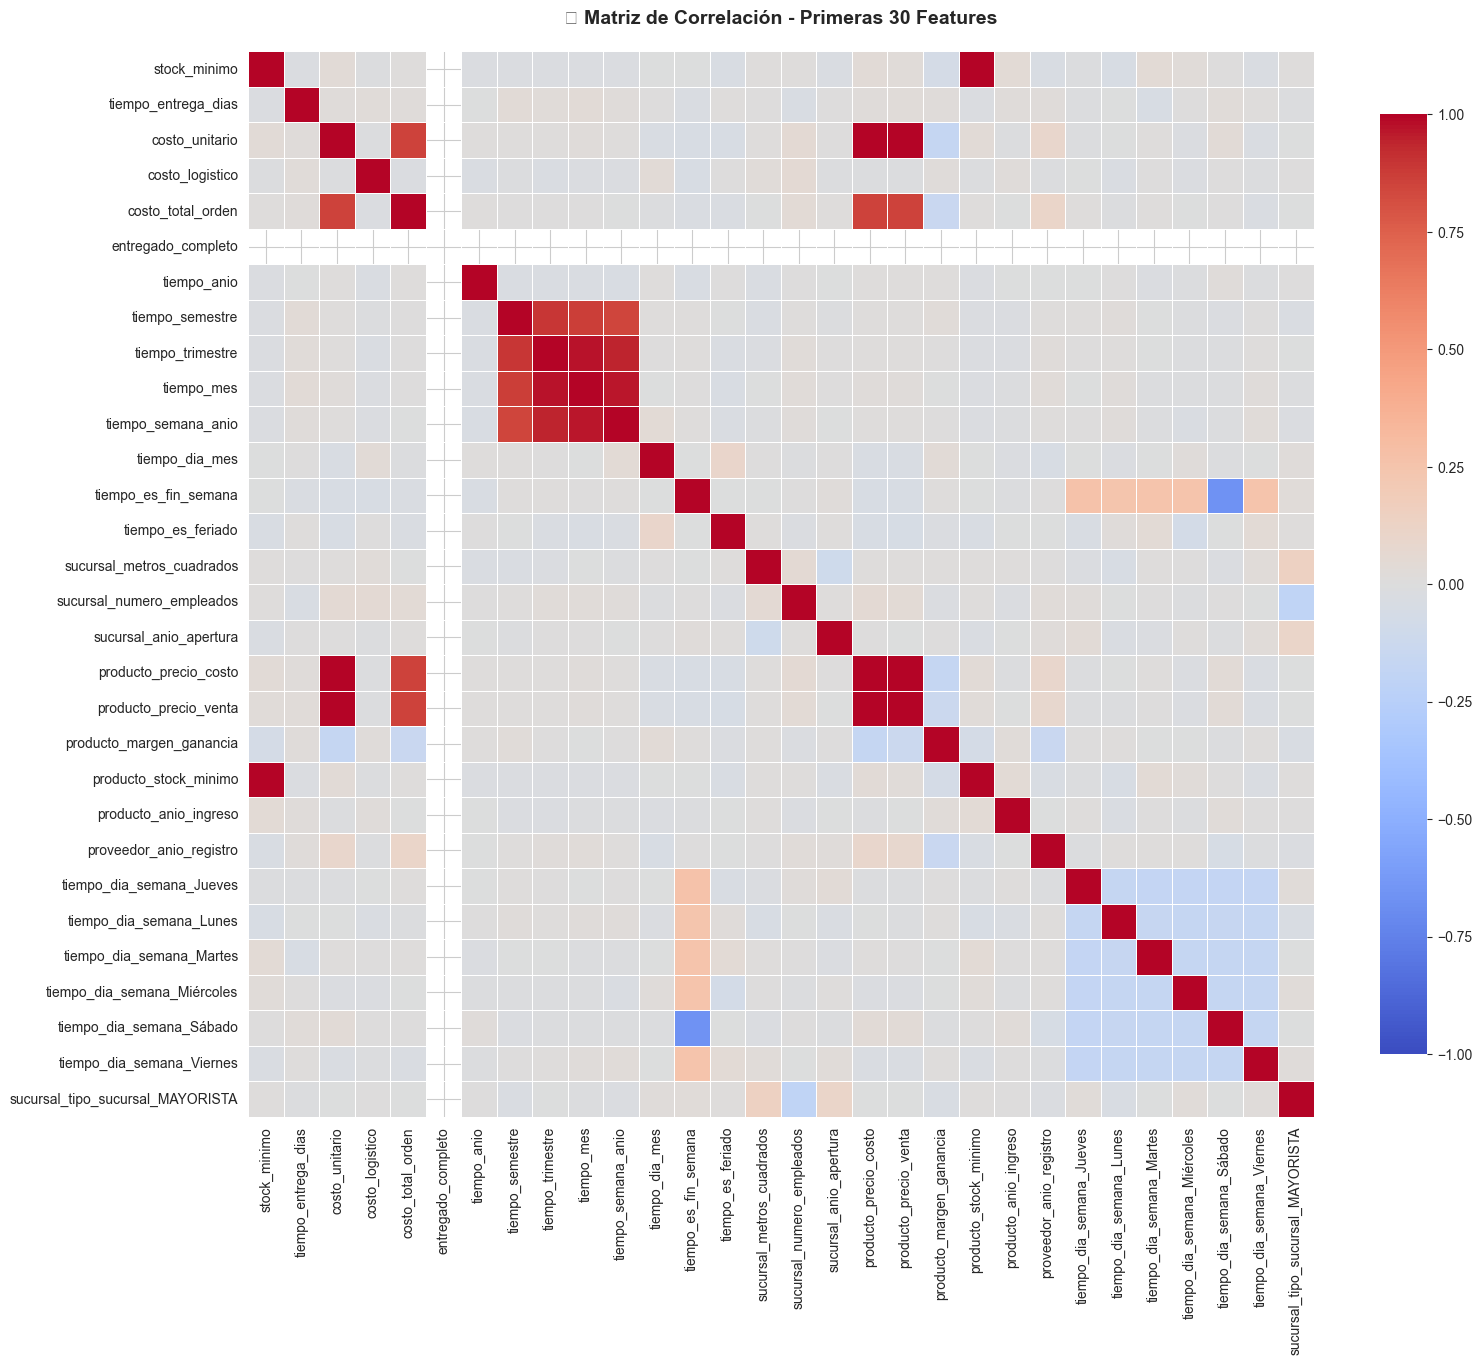

✅ Heatmap guardado


In [10]:
# Matriz de correlación
corr_matrix = df_encoded.corr()

# Visualizar heatmap
fig, ax = plt.subplots(figsize=(16, 14))
n_features_display = min(30, df_encoded.shape[1])
corr_subset = corr_matrix.iloc[:n_features_display, :n_features_display]

sns.heatmap(corr_subset, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            ax=ax, vmin=-1, vmax=1)
ax.set_title(f'🔥 Matriz de Correlación - Primeras {n_features_display} Features', 
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('outputs/01_correlacion_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Heatmap guardado")

In [11]:
# Detectar pares altamente correlacionados
def find_highly_correlated_pairs(corr_matrix, threshold=0.9):
    pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                pairs.append({
                    'feature1': corr_matrix.columns[i],
                    'feature2': corr_matrix.columns[j],
                    'correlacion': corr_matrix.iloc[i, j]
                })
    return pd.DataFrame(pairs).sort_values('correlacion', ascending=False, key=abs)

highly_corr = find_highly_correlated_pairs(corr_matrix, threshold=0.9)
print(f"🔴 Features correlacionadas (> 0.9): {len(highly_corr)}")
if len(highly_corr) > 0:
    print(highly_corr.head(10).to_string())

🔴 Features correlacionadas (> 0.9): 51
                                 feature1                            feature2  correlacion
0                            stock_minimo               producto_stock_minimo          1.0
1                          costo_unitario               producto_precio_costo          1.0
10               sucursal_ciudad_GUARANDA          sucursal_provincia_BOLIVAR          1.0
15                sucursal_ciudad_MACHALA           sucursal_provincia_EL ORO          1.0
9   sucursal_ciudad_FRANCISCO DE ORELLANA         sucursal_provincia_ORELLANA          1.0
8              sucursal_ciudad_ESMERALDAS       sucursal_provincia_ESMERALDAS          1.0
7                 sucursal_ciudad_AZOGUES            sucursal_provincia_CAÑAR          1.0
14                  sucursal_ciudad_MACAS  sucursal_provincia_MORONA SANTIAGO          1.0
13                   sucursal_ciudad_LOJA             sucursal_provincia_LOJA          1.0
12              sucursal_ciudad_LATACUNGA         s

In [12]:
# PCA previo a t-SNE para reducir dimensionalidad (Soluciona el problema de las 1300+ columnas)
print("⏳ Reduciendo dimensionalidad con PCA antes de t-SNE...")
pca_tsne = PCA(n_components=min(50, X_scaled.shape[1]))
X_pca_for_tsne = pca_tsne.fit_transform(X_scaled)

# t-SNE
print("⏳ Calculando t-SNE 2D...")
tsne = TSNE(n_components=2, perplexity=min(30, len(X_scaled)//3), random_state=42, max_iter=1000, n_jobs=-1)
X_tsne = tsne.fit_transform(X_pca_for_tsne)
print(f"✅ t-SNE completado")


⏳ Reduciendo dimensionalidad con PCA antes de t-SNE...


⏳ Calculando t-SNE 2D...


✅ t-SNE completado


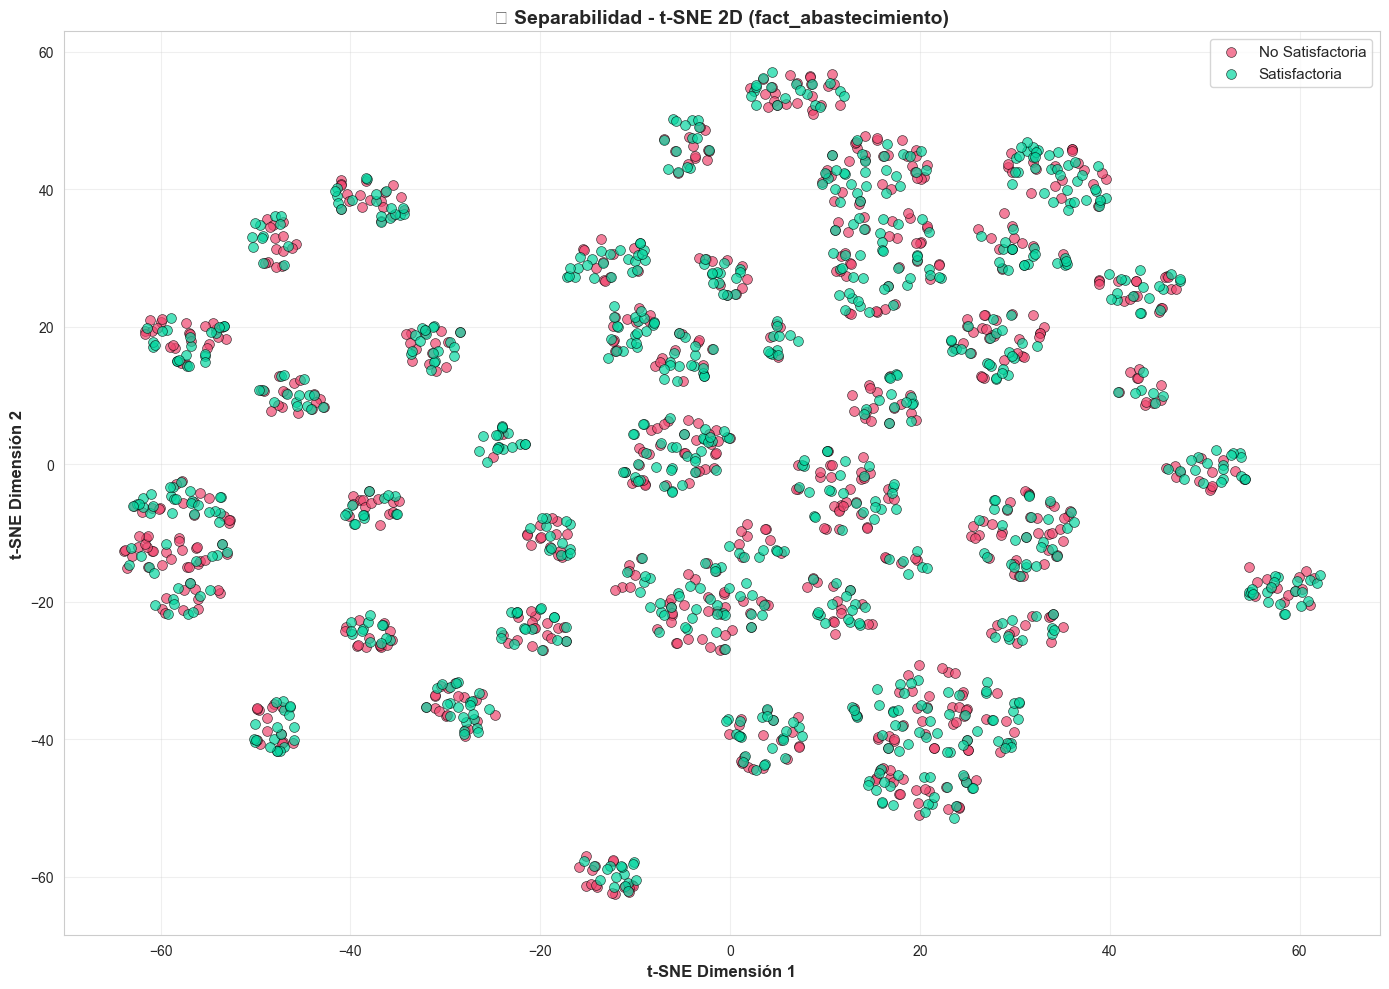

✅ Gráfico t-SNE guardado


In [13]:
# Visualizar t-SNE
fig, ax = plt.subplots(figsize=(14, 10))
colors = ['#EF476F', '#06D6A0']
class_names = ['No Satisfactoria', 'Satisfactoria']

for i, (class_val, color, name) in enumerate(zip(sorted(y.unique()), colors, class_names)):
    mask = y == class_val
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=color, label=name, s=50, alpha=0.7, edgecolors='black', linewidth=0.5)

ax.set_xlabel('t-SNE Dimensión 1', fontsize=12, fontweight='bold')
ax.set_ylabel('t-SNE Dimensión 2', fontsize=12, fontweight='bold')
ax.set_title('🎯 Separabilidad - t-SNE 2D (fact_abastecimiento)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/02_tsne_separabilidad.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Gráfico t-SNE guardado")

In [14]:
# Métricas de separabilidad
silhouette = silhouette_score(X_scaled, y)
davies_bouldin = davies_bouldin_score(X_scaled, y)

print(f"\n📊 MÉTRICAS DE SEPARABILIDAD:")
print(f"Silhouette Score: {silhouette:.4f} {'✅' if silhouette > 0.5 else '⚠️' if silhouette > 0.3 else '🔴'}")
print(f"Davies-Bouldin: {davies_bouldin:.4f} {'✅' if davies_bouldin < 1 else '⚠️'}")


📊 MÉTRICAS DE SEPARABILIDAD:
Silhouette Score: -0.0015 🔴
Davies-Bouldin: 41.5312 ⚠️


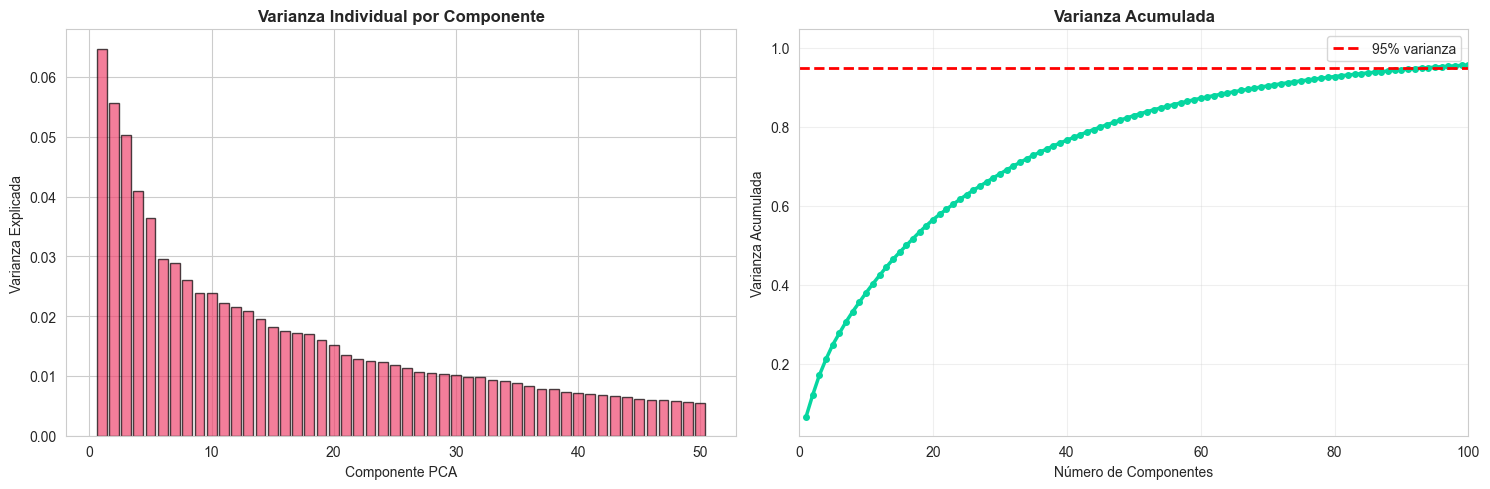


📈 PCA ANALYSIS:
Features actuales: 317
Componentes para 95% varianza: 94
Reducción posible: 70.3%


In [15]:
# PCA - Varianza explicada
pca = PCA()
pca.fit(X_scaled)
cumsum_var = np.cumsum(pca.explained_variance_ratio_)
n_components_95 = np.argmax(cumsum_var >= 0.95) + 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.bar(range(1, min(51, len(pca.explained_variance_ratio_)+1)), 
        pca.explained_variance_ratio_[:50], color='#EF476F', alpha=0.7, edgecolor='black')
ax1.set_title('Varianza Individual por Componente', fontsize=12, fontweight='bold')
ax1.set_xlabel('Componente PCA')
ax1.set_ylabel('Varianza Explicada')

ax2.plot(range(1, len(cumsum_var)+1), cumsum_var, 'o-', color='#06D6A0', linewidth=2.5, markersize=4)
ax2.axhline(0.95, color='red', linestyle='--', linewidth=2, label='95% varianza')
ax2.set_title('Varianza Acumulada', fontsize=12, fontweight='bold')
ax2.set_xlabel('Número de Componentes')
ax2.set_ylabel('Varianza Acumulada')
ax2.set_xlim(0, min(100, len(cumsum_var)))
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/03_pca_varianza.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📈 PCA ANALYSIS:")
print(f"Features actuales: {X_scaled.shape[1]}")
print(f"Componentes para 95% varianza: {n_components_95}")
print(f"Reducción posible: {(1 - n_components_95/X_scaled.shape[1])*100:.1f}%")

In [16]:
# Resumen final
resumen = pd.DataFrame({
    'Métrica': ['Muestras', 'Features', 'Ratio', 'Silhouette', 'Davies-Bouldin', 'Pares Correlacionados', 'PCA 95% var.'],
    'Valor': [X_scaled.shape[0], X_scaled.shape[1], f"1:{X_scaled.shape[1]/X_scaled.shape[0]:.2f}", 
              f"{silhouette:.4f}", f"{davies_bouldin:.4f}", len(highly_corr), n_components_95],
})
print("\n📊 TABLA RESUMEN:")
print(resumen.to_string(index=False))
resumen.to_csv('outputs/00_resumen_analisis.csv', index=False)


📊 TABLA RESUMEN:
              Métrica   Valor
             Muestras    2500
             Features     317
                Ratio  1:0.13
           Silhouette -0.0015
       Davies-Bouldin 41.5312
Pares Correlacionados      51
         PCA 95% var.      94


In [17]:
# Exportar datos preprocesados para el Notebook 02
import numpy as np
import os
os.makedirs('outputs', exist_ok=True)
np.savez('outputs/01_processed_data.npz', X_scaled=X_scaled, y=y)
print("✅ Datos preprocesados (X_scaled, y) guardados exitosamente en outputs/01_processed_data.npz")

✅ Datos preprocesados (X_scaled, y) guardados exitosamente en outputs/01_processed_data.npz
